# Домашнє завдання до модуля «Алгоритми навчання з вчителем Ч.2»
## Декларуємо функції
### Функція показу графіка теплоти кореляції за ознаками

In [25]:
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer


def draw_heatmap(data):
    plt.figure(figsize=(9, 13))
    
    ax = sns.heatmap(data,
            cmap='Blues',
            linewidth=0.5,
            square=True,
            cbar_kws=dict(
              location="bottom",
              pad=0.01,
              shrink=0.25))
    
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', labelrotation=90)
    
    plt.show()

### Функція показу графіка розподілу числових ознак

In [26]:
def show_num_features_dist(data):
    melted = data.melt()
     
    g = sns.FacetGrid(melted,
                       col='variable',
                       col_wrap=4,
                       sharex=False,
                       sharey=False,
                       aspect=1.25)
     
    g.map(sns.histplot, 'value')
     
    g.set_titles(col_template='{col_name}')
     
    g.tight_layout()
     
    plt.show()

### Функція підготовки датафрейму для моделі часових ознак Prophet
Для аналізу часових ознак за часовим рядом.

In [27]:
import numpy as np


def prepare_prophet_df(df, date_col, target_col_data: np.ndarray=np.nan):
    # Копія, щоб не змінювати оригінал
    d = df.copy()

    # Переведення колонки дати у datetime
    d[date_col] = pd.to_datetime(d[date_col], errors='coerce')
    if d[date_col].isna().any():
        # Видаліть або обробіть некоректні дати
        d = d.dropna(subset=[date_col])

    # Перейменування у формат Prophet
    d = d.rename(columns={date_col: "ds"})

    d['y'] = target_col_data

    return d

### Функція підготовки, обробки, кодування та нормалізації вхідного датафрейма

In [28]:
import pandas as pd

yes_no_map = {"No": 0, "Yes": 1}

def map_col(x: pd.DataFrame) -> pd.DataFrame:
    x = x.copy()
    x["RainToday"] = x["RainToday"].map(yes_no_map)
    x["RainTomorrow"] = x["RainTomorrow"].map(yes_no_map)
    return x

def prepare_dataframe(df: pd.DataFrame, date_col: str, exclusion_cols: list=None, custom_encoder: tuple=None):
    df[date_col] = pd.to_datetime(df[date_col])
    X = df.drop(columns=date_col)

    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist() if not exclusion_cols else X.select_dtypes(include=["object", "category", "bool"]).drop(columns=exclusion_cols).columns.tolist()

    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

    custom_preprocess = None

    if custom_encoder:
        custom_preprocess = Pipeline(steps=[custom_encoder])

    categorical_preprocess = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot_encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numeric_preprocess = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True))
    ])

    if custom_preprocess:
        preprocess = ColumnTransformer(
        transformers=[
            ("cat", categorical_preprocess, categorical_cols),
            ("num", numeric_preprocess, numeric_cols),
            ("custom", custom_preprocess, exclusion_cols)
        ],
        remainder="drop"
    )
    else:
        preprocess = ColumnTransformer(
            transformers=[
                ("cat", categorical_preprocess, categorical_cols),
                ("num", numeric_preprocess, numeric_cols),
            ],
            remainder="drop"
        )

    model = Pipeline(steps=[
        ("prep", preprocess)
    ])

    X_enc = model.fit_transform(X)

    ohe = model.named_steps["prep"].named_transformers_["cat"].named_steps["one_hot_encoder"]
    list(ohe.get_feature_names_out(categorical_cols)) + numeric_cols

    # Отримати колонки з ColumnTransformer
    ct = model.named_steps["prep"]  # ваш ColumnTransformer усередині пайплайну
    feature_names = ct.get_feature_names_out()

    # Перетворити у щільний масив за потреби
    from scipy import sparse
    X_enc_dense = X_enc.toarray() if sparse.issparse(X_enc) else X_enc

    # Зібрати єдиний DataFrame ознак
    X_enc_df = pd.DataFrame(X_enc_dense, columns=feature_names, index=df.index)

    # За потреби повернути дату (якщо її відкинули до трансформацій)
    X_full = X_enc_df.join(df[[date_col]])

    return X_full

## Завантаження даних

In [29]:
import kagglehub
import pandas as pd
from mypy.util import os_path_join
from setuptools.compat.py311 import shutil_rmtree

path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")
csv_path = os_path_join(path, "weatherAUS.csv")
csv_path

100%|██████████| 3.83M/3.83M [00:00<00:00, 4.88MB/s]

Extracting files...


'/Users/kozak_mamay/.cache/kagglehub/datasets/jsphyg/weather-dataset-rattle-package/versions/2/weatherAUS.csv'

## Створення датафрейму

In [30]:
import pandas as pd
import shutil

df = pd.read_csv(csv_path)

shutil.rmtree(path)

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## Виводимо загальну інформацію по датафрейму

In [31]:
df.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

In [32]:
df.isna().mean().sort_values(ascending=False)

Sunshine         0.480098
Evaporation      0.431665
Cloud3pm         0.408071
Cloud9am         0.384216
Pressure9am      0.103568
Pressure3pm      0.103314
WindDir9am       0.072639
WindGustDir      0.070989
WindGustSpeed    0.070555
Humidity3pm      0.030984
WindDir3pm       0.029066
Temp3pm          0.024811
RainTomorrow     0.022460
Rainfall         0.022419
RainToday        0.022419
WindSpeed3pm     0.021050
Humidity9am      0.018246
Temp9am          0.012148
WindSpeed9am     0.012148
MinTemp          0.010209
MaxTemp          0.008669
Location         0.000000
Date             0.000000
dtype: float64

## Виводимо мапу теплоти кореляції ознак, погрупованих по локації

/var/folders/9f/3qm3m8k90w108hgmspdbjnph0000gn/T/ipykernel_2284/1216273656.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:


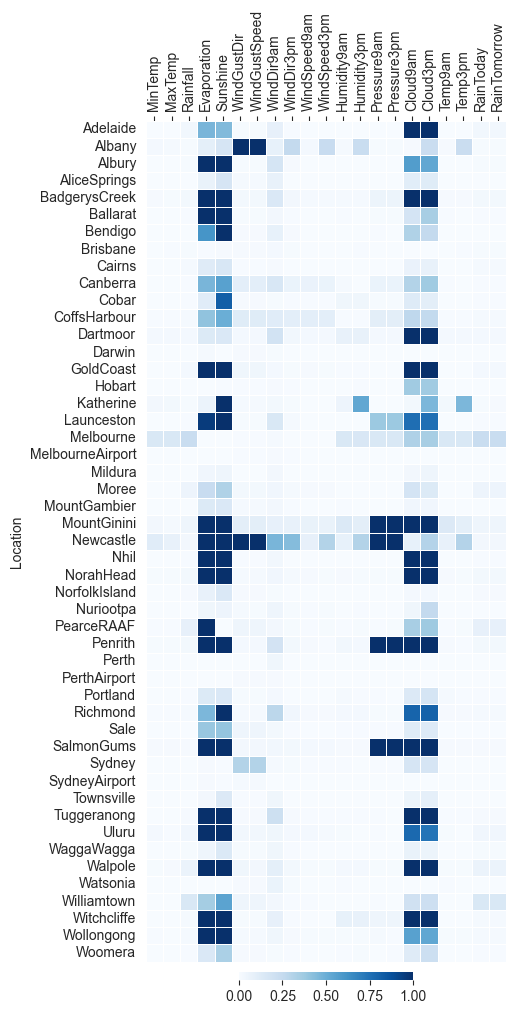

In [33]:
tmp = (df
       .groupby('Location')
       .apply(lambda x:
           x.drop(['Location', 'Date'], axis=1)
           .isna()
           .mean()))

draw_heatmap(tmp)

## Викидаємо експерименти з великим відсотком пропущених даних

In [34]:
df = df[df.columns[df.isna().mean().lt(0.35)]]
     
df = df.dropna(subset='RainTomorrow').dropna(subset='RainToday')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No


## Виводимо графіки розподілу числових ознак

In [35]:
import numpy as np

data_num = df.select_dtypes(include=np.number)
data_num.head()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7


In [36]:
data_cat = df.select_dtypes(include='object')
data_cat.head()

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,W,W,WNW,No,No
1,2008-12-02,Albury,WNW,NNW,WSW,No,No
2,2008-12-03,Albury,WSW,W,WSW,No,No
3,2008-12-04,Albury,NE,SE,E,No,No
4,2008-12-05,Albury,W,ENE,NW,No,No


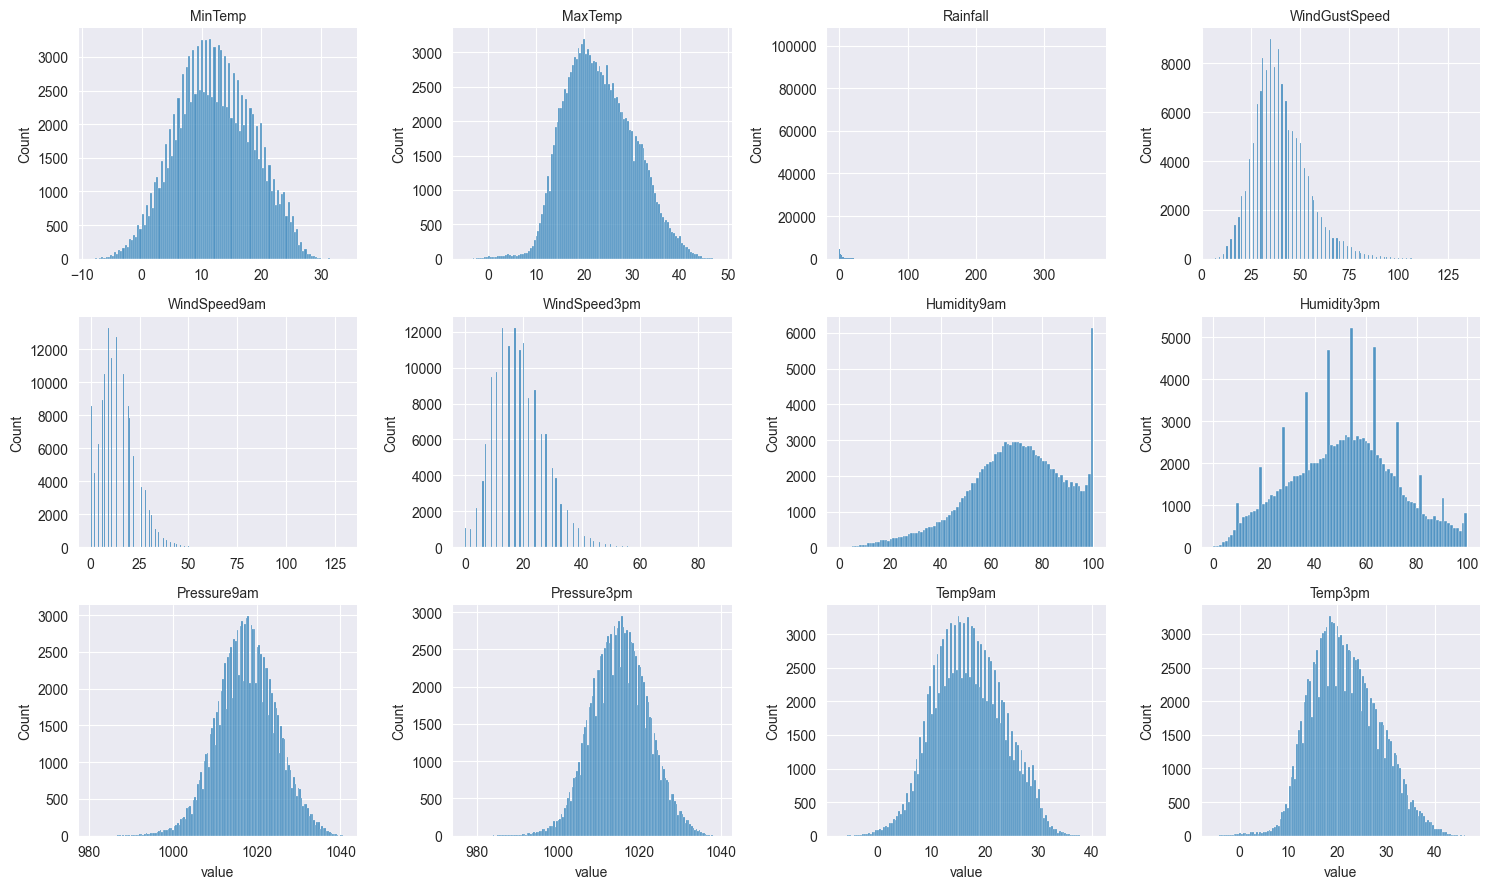

In [37]:
show_num_features_dist(data_num)

З ізуалізації бачимо, що більшість ознак більш чи менш мають нормальний розподіл Гаусса - Лапласа. Ознака *Rainfall* має обмаль даних.

## Аналізуємо категоріальні ознаки

In [38]:
data_cat.nunique()

Date            3436
Location          49
WindGustDir       16
WindDir9am        16
WindDir3pm        16
RainToday          2
RainTomorrow       2
dtype: int64

In [39]:
data_cat.apply(lambda x: x.unique()[:5])

Date            [2008-12-01, 2008-12-02, 2008-12-03, 2008-12-0...
Location        [Albury, BadgerysCreek, Cobar, CoffsHarbour, M...
WindGustDir                                [W, WNW, WSW, NE, NNW]
WindDir9am                                  [W, NNW, SE, ENE, SW]
WindDir3pm                                   [WNW, WSW, E, NW, W]
RainToday                                               [No, Yes]
RainTomorrow                                            [No, Yes]
dtype: object

## Підготовка, нармалізація та кодування даних перед використанням
Ми кодуємо усі категоріальні ознаки, окрім *RainToday* i *RainTomorrow* через **OneHotEncoder**. Але означені ознаки мають лише 2 значення:
- Yes
- No

Ми хлчемо кодувати *Yes*, як *1*, натомість *No*, як *2*. Це ми робитимемо через функціональний енкодер з застосуванням цільової функції.

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from imblearn.pipeline import Pipeline

df = prepare_dataframe(df, "Date", exclusion_cols=["RainToday", "RainTomorrow"], custom_encoder=("custom_encoder", FunctionTransformer(map_col, feature_names_out="one-to-one")))

df.head()

,cat__Location_Adelaide,cat__Location_Albany,cat__Location_Albury,cat__Location_AliceSprings,cat__Location_BadgerysCreek,cat__Location_Ballarat,cat__Location_Bendigo,cat__Location_Brisbane,cat__Location_Cairns,cat__Location_Canberra,...,num__WindSpeed3pm,num__Humidity9am,num__Humidity3pm,num__Pressure9am,num__Pressure3pm,num__Temp9am,num__Temp3pm,custom__RainToday,custom__RainTomorrow,Date
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.615022,0.113946,-1.433926,-1.474141,-1.219942,-0.013228,0.017149,0.0,0.0,2008-12-01
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.385631,-1.310031,-1.287920,-1.044459,-1.115191,0.033062,0.380877,0.0,0.0,2008-12-02
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.844412,-1.626470,-1.044576,-1.488958,-0.980512,0.619403,0.220837,0.0,0.0,2008-12-03
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.105406,-1.257291,-1.725938,-0.007297,-0.366971,0.171932,0.700958,0.0,0.0,2008-12-04
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.156241,0.694085,-0.898570,-1.014826,-1.384551,0.125642,1.166530,0.0,0.0,2008-12-05


## Робимо попереднє розбиття даних на тренувальні і тестові для того, щоб проаналізувати часові ознаки через модель часових рядів

In [41]:
from sklearn.model_selection import train_test_split
X = df.drop(columns='custom__RainToday')
y = df['custom__RainToday']
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train_1 = prepare_prophet_df(X_train_1, "Date", target_col_data=y_train_1)
X_test_1 = prepare_prophet_df(X_test_1, "Date")

In [42]:
X_train_1.head()

,cat__Location_Adelaide,cat__Location_Albany,cat__Location_Albury,cat__Location_AliceSprings,cat__Location_BadgerysCreek,cat__Location_Ballarat,cat__Location_Bendigo,cat__Location_Brisbane,cat__Location_Cairns,cat__Location_Canberra,...,num__WindSpeed3pm,num__Humidity9am,num__Humidity3pm,num__Pressure9am,num__Pressure3pm,num__Temp9am,num__Temp3pm,custom__RainTomorrow,ds,y
123230,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.187845,-0.888112,-0.168539,0.155686,0.141819,0.681124,0.453623,0.0,2015-11-03,0.0
71385,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.876016,-2.364828,-1.433926,0.570550,0.680537,1.329185,1.181079,0.0,2011-10-20,0.0
44749,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.417235,0.852304,1.340192,-0.096197,-0.307114,0.742844,0.395426,0.0,2015-03-11,0.0
94829,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.385631,-1.099071,-0.217208,0.496467,0.515929,0.727414,0.599114,0.0,2013-05-27,0.0
27344,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.449492,1.590663,0.561492,-1.355608,-1.489301,-1.263061,-0.972190,0.0,2009-06-27,0.0


## Будуємо пробну модель часового ряду за допомогою бібліотеки Prophet та робимо прогноз

In [43]:
from prophet import Prophet

t_model = Prophet()
t_model.fit(X_train_1)

t_pred = t_model.predict(X_test_1)

23:14:01 - cmdstanpy - INFO - Chain [1] start processing
23:14:07 - cmdstanpy - INFO - Chain [1] done processing


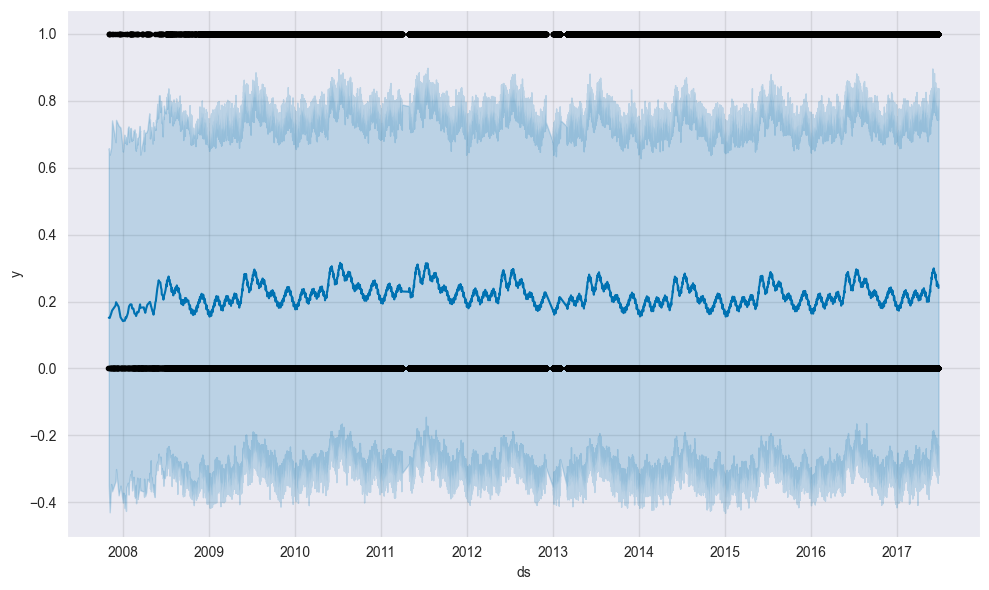

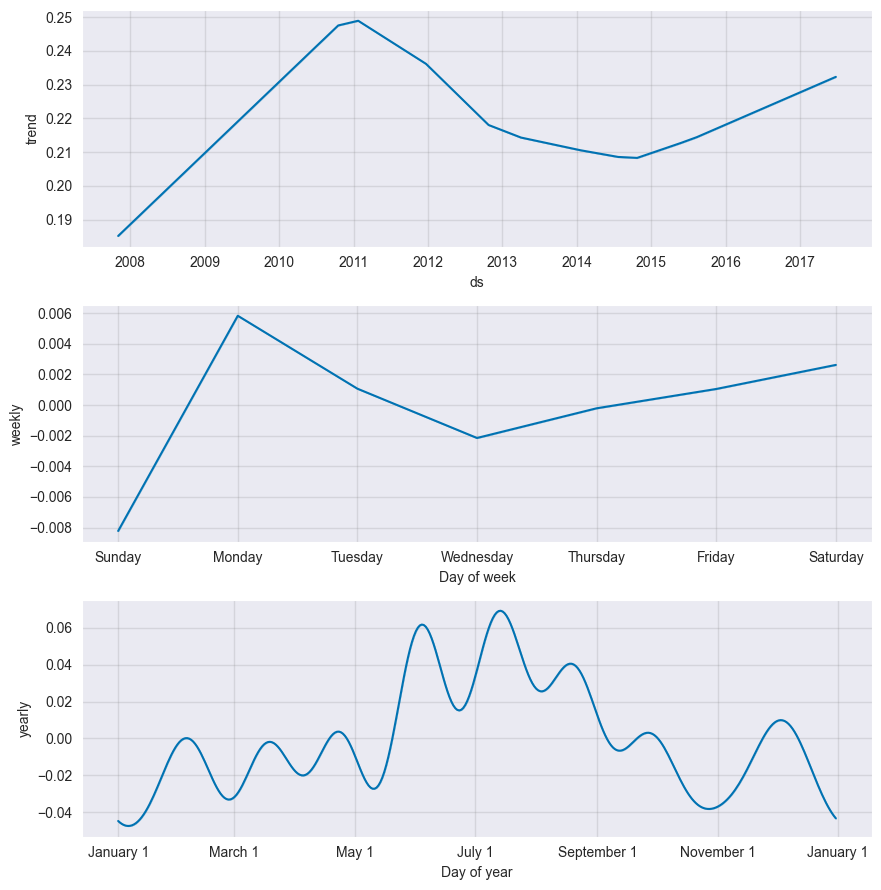

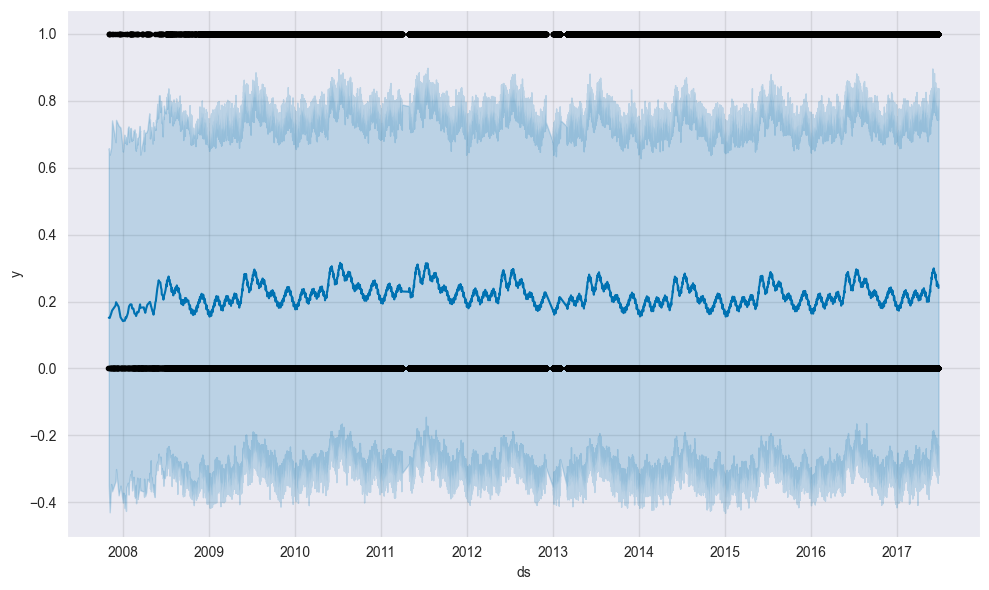

In [44]:
t_model.plot_components(t_pred)
t_model.plot(t_pred)

## Аналізуємо акуратність моделі часового ряду

In [45]:
from sklearn.metrics import median_absolute_error, classification_report

approx_mape = median_absolute_error(t_pred["yhat"], y_test_1)

print(f'Accuracy: {1 - approx_mape:.1%}')

Accuracy: 76.9%


Навіть з нашим попереднім розбиттям маємо доволі непогану модель з 77% акуратності.

## Перетворюємо часову ознаку на групу числових
Згідно з умовами завдання ми виділяємо з поля *Date* числові поля *Year* i *Month* та видаляємо останнє нечислове поле.

In [46]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df.drop(columns="Date", inplace=True)
df.head()

,cat__Location_Adelaide,cat__Location_Albany,cat__Location_Albury,cat__Location_AliceSprings,cat__Location_BadgerysCreek,cat__Location_Ballarat,cat__Location_Bendigo,cat__Location_Brisbane,cat__Location_Cairns,cat__Location_Canberra,...,num__Humidity9am,num__Humidity3pm,num__Pressure9am,num__Pressure3pm,num__Temp9am,num__Temp3pm,custom__RainToday,custom__RainTomorrow,Year,Month
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.113946,-1.433926,-1.474141,-1.219942,-0.013228,0.017149,0.0,0.0,2008,12
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.310031,-1.287920,-1.044459,-1.115191,0.033062,0.380877,0.0,0.0,2008,12
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.626470,-1.044576,-1.488958,-0.980512,0.619403,0.220837,0.0,0.0,2008,12
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.257291,-1.725938,-0.007297,-0.366971,0.171932,0.700958,0.0,0.0,2008,12
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.694085,-0.898570,-1.014826,-1.384551,0.125642,1.166530,0.0,0.0,2008,12


## Розбиваємо дані на тренувальні та тестові згідно із завданням

Розбийте підмножини на тренувальну і тестову вибірки за такою логікою: до тестової вибірки віднесіть всі об'єкти із набору даних із останнім (максимальним) роком спостережень, а для навчання моделі залиште всі інші об'єкти.

In [47]:
df_sorted = df.sort_values("Year")

last_year = df_sorted["Year"].max()

test_mask = df_sorted["Year"] == last_year

test = df_sorted[test_mask]
train = df_sorted[~test_mask]

X = df_sorted.drop(columns='custom__RainToday')
y = df_sorted['custom__RainToday']

X_train_2, y_train_2 = X.loc[train.index], y.loc[train.index]
X_test_2, y_test_2 = X.loc[test.index], y.loc[test.index]

## Створюємо навчальну кластеризаційну модель на основі логістичної регресії

Після багатьох експериментів я дійшов до висновку, що найкраще підходить з солвером за умовчанням але із збільшеною максимальною кількістю ітерацій

In [55]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

clf.fit(X_train_2, y_train_2)

/Users/kozak_mamay/PycharmProjects/WoolfDataScience/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Застосовуємо побудовану модель та виводимо звіт по проведеній кластеризації

In [56]:
clf_pred = clf.predict(X_test_2)

print(classification_report(y_test_2, clf_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6628
         1.0       1.00      0.99      1.00      1741

    accuracy                           1.00      8369
   macro avg       1.00      1.00      1.00      8369
weighted avg       1.00      1.00      1.00      8369



Із звіту бачимо, що модель аж занадто акуратна (цілих 100% майже за всіма метриками). Це може бути повʼязано із тим, що на тренування ми виділили переважну більшість даних. В пркатиці це також може означати перенавчання.